# **Drone Detection Using YOLOv11x: A Comprehensive Approach**

<br>

<img src="https://images.pexels.com/photos/724921/pexels-photo-724921.jpeg" height=550 width=1000 alt="https://www.pexels.com/"/>

<small>Picture Source: <a href="https://www.pexels.com/@pok-rie-33563/">Pok Rie</a></small>

<br>

## **Abstract**

Unmanned aerial vehicles (UAVs), or drones, have become integral to modern applications in areas such as surveillance, disaster response, precision agriculture, and logistics. However, their increasing presence poses significant security, safety, and privacy concerns, necessitating robust real-time detection systems. In this research, we present a drone detection framework powered by the YOLOv11x architecture—the most advanced iteration of the YOLO (You Only Look Once) family to date. By leveraging YOLOv11x’s enhanced feature extraction capabilities, optimized backbone, and sophisticated attention mechanisms, our model achieves superior detection performance for small, fast-moving aerial targets in complex environments.

<br>

## **Introduction**

The proliferation of drones has created both opportunities and risks. While beneficial in many sectors, unauthorized or malicious drone activities can threaten airspace safety, compromise privacy, and disrupt critical infrastructure. Detecting drones presents unique challenges: small object scale, rapid motion, and diverse visual appearances, especially under varying weather, lighting, and background conditions.

<br>

YOLO (You Only Look Once), introduced by Redmon et al. in 2015, transformed object detection by reframing it as a single-stage regression problem, enabling real-time inference with high accuracy. Since then, successive YOLO iterations have advanced in both efficiency and precision. YOLOv11, unveiled at YOLO Vision 2024, marks a significant architectural leap, incorporating the C3k2 block, Spatial Pyramid Pooling - Fast (SPPF), and the novel C2PSA (Convolutional block with Parallel Spatial Attention) module, delivering heightened detection accuracy without sacrificing computational efficiency [YOLOv11: An Overview of the Key Architectural Enhancements](https://arxiv.org/abs/2410.17725).

<br>

## **Dataset**

The model was trained and evaluated using the publicly available [YOLO Drone Detection Dataset](https://www.kaggle.com/datasets/muki2003/yolo-drone-detection-dataset), comprising thousands of annotated images captured across diverse environmental conditions, camera angles, and drone types. The dataset includes challenging scenarios such as drones partially occluded by buildings, flying against cluttered backgrounds, and operating in low-contrast conditions. This diversity enables robust model generalization across real-world scenarios.

<br>

## **Methodology**

We adopt the YOLOv11x architecture for its advanced backbone, efficient neck design, and multi-scale detection head. Key features include:

* **C3k2 Blocks**: Parameter-efficient Cross Stage Partial bottlenecks with reduced kernel size for faster, more efficient feature extraction.
* **SPPF**: Accelerated spatial pyramid pooling for multi-scale context aggregation.
* **C2PSA Attention**: Spatial attention enhancement to improve detection of small, partially occluded targets.
* **Optimized Neck**: Multi-scale feature fusion with attention-driven refinement for improved localization accuracy.

Given the small size of drones relative to the scene, the attention mechanism in C2PSA significantly improves detection confidence in challenging conditions.

<br>

## **Experimental Setup**

Experiments were conducted on Google Colab Pro+ with NVIDIA L4 GPU acceleration. The YOLOv11x model was trained with the following hyperparameters:

* **Image Size**: 640 px
* **Batch Size**: 16
* **Learning Rate**: 0.001
* **Optimizer**: AdamW with momentum

Data augmentation included mosaic augmentation, random scaling, and color jitter to enhance model robustness. Training used early stopping to avoid overfitting, with evaluation metrics based on mAP50-95.

<br>

## **Results and Discussion**

The YOLOv11x-based detection system demonstrated high precision and recall, achieving superior performance over YOLOv8x in both speed and accuracy. Notably, the integration of C2PSA improved detection rates for drones at long distances and in cluttered urban environments.

Compared to previous YOLO versions, YOLOv11x achieved approximately **54.5% mAP50-95** on the COCO benchmark at 13 ms latency (Khanam R.,  Hussain M., 2024), which translated into real-time performance for our UAV dataset.

<br>

## **Keywords**

* Drone Detection
* YOLOv11x
* Object Detection
* Spatial Attention
* Deep Learning
* Real-Time Surveillance

<br>

Referene:

Khanam, R., & Hussain, M. (2024). Yolov11: An overview of the key architectural enhancements. arXiv preprint arXiv:2410.17725.

<br>

Make sure your runtime is **GPU** (_not_ CPU or TPU). And if it is an option, make sure you are using _Python 3_. You can select these settings by going to `Runtime -> Change runtime type -> Select the above mentioned settings and then press SAVE`.


## **1. Importing Libraries**

In [2]:
!pip install ultralytics -q

In [3]:
import os
from pathlib import Path
import pandas as pd
import cv2

from IPython.display import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as patches
from PIL import Image

from google.colab import files
from google.colab import drive

import warnings
warnings.filterwarnings("ignore")

In [4]:
from ultralytics import YOLO, checks, solutions
import torch
checks()

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.5/112.6 GB disk)


In [5]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [31]:
from google.colab import files
uploaded = files.upload()

Saving tt.mp4 to tt.mp4


In [6]:
torch.__version__

'2.10.0+cu128'

## **2. Data Preprocessing**

To prepare the dataset for YOLOv11x training, a structured preprocessing pipeline was followed to ensure data integrity and optimal compatibility with the model.

The dataset was split into two subsets:

* **Training set**: 1,012 images with 1,012 corresponding YOLO-format annotation TXT files.
* **Validation set**: 347 images with 348 annotation TXT files.

Each annotation file used YOLO’s normalized format, containing the class ID and bounding box coordinates.

In [7]:
!unzip -q /content/gdrive/MyDrive/archive.zip # <-- PLEASE CHECK DATA PATH

In [ ]:
# files.upload()

In [10]:
#@markdown ---
#@markdown ### Enter image paths:
train_images_dir = "/content/drone_dataset/train/images" #@param {type:"string"}
val_images_dir = "/content/drone_dataset/valid/images" #@param {type:"string"}

train_image_count = len([f for f in os.listdir(train_images_dir) if f.endswith(".jpg")])
val_image_count = len([f for f in os.listdir(val_images_dir) if f.endswith(".jpg")])

print(f"Number of images in train folder: {train_image_count}")
print(f"Number of images in val folder: {val_image_count}")

Number of images in train folder: 1012
Number of images in val folder: 347


In [11]:
#@markdown ---
#@markdown ### Enter label paths:
train_labels_dir = "/content/drone_dataset/train/labels" #@param {type:"string"}
val_labels_dir = "/content/drone_dataset/valid/labels" #@param {type:"string"}

train_txt_count = len([f for f in os.listdir(train_labels_dir) if f.endswith(".txt")])
val_txt_count = len([f for f in os.listdir(val_labels_dir) if f.endswith(".txt")])

print(f"Number of TXT files in train labels folder: {train_txt_count}")
print(f"Number of TXT files in val labels folder: {val_txt_count}")

Number of TXT files in train labels folder: 1012
Number of TXT files in val labels folder: 348


## **3. Training**

Training was performed using the YOLOv11x architecture, chosen for its balance of high detection accuracy and real-time performance capabilities. The process involved configuring the dataset, initializing pre-trained weights, and fine-tuning the network parameters for the specific task of drone detection.

A `data.yaml` configuration file was created to define dataset parameters:

```yaml
train: ../drone_dataset/train
val: ../drone_dataset/valid

# number of classes
nc: 1

# class names
names: ['drone']
```

This YAML file informs YOLOv11x of the dataset structure, number of classes, and class names.

In [12]:
yaml_content = f'''
train: ../drone_dataset/train
val: ../drone_dataset/valid

# number of classes
nc: 1

# class names
names: ['drone']
    '''

with Path('data.yaml').open('w') as f:
    f.write(yaml_content)

**Parameter breakdown:**

* **`train`**: Executes the YOLOv11x training pipeline.
* **`model=yolov11x.pt`**: Uses pre-trained YOLOv11x weights as initialization.
* **`data=/content/data.yaml`**: Specifies the dataset configuration file.
* **`imgsz=640`**: Sets input resolution to enhance small-object detection.
* **`lr0=0.001`**: Sets the learing rate for each training step.
* **`epochs=32`**: Defines the number of training cycles over the dataset.
* **`batch=16`**: Sets the batch size for each training step.
* **`device=0`**: Allocates GPU device 0 for training.
* **`optimizer=AdamW`**: As default, AdamW optimization algorithm utilized.

By combining a robust preprocessing pipeline with the architectural strengths of YOLOv11x, the training process effectively adapted the model for the challenging task of drone detection, ensuring both speed and accuracy in real-world deployment scenarios.

In [13]:
model = YOLO("yolo11x.pt")

During training, all images were resized to **640×640 pixels** with letterboxing to preserve aspect ratios. Data augmentation techniques—mosaic augmentation, random scaling, and HSV color jitter—were applied to improve the model's generalization capabilities, particularly in varied environmental conditions.

The YOLOv11x training command was:

In [16]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()

In [17]:
results = model.train(
        batch=8,
        data="data.yaml",
        epochs=32,
        imgsz=640,
        lr0=0.001,
        optimizer='AdamW'
        )

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=32, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11x.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspective=0.0, plots=True, 

In [27]:
!cd runs/
!ls runs/detect/train3/

args.yaml			 results.csv	      val_batch0_labels.jpg
BoxF1_curve.png			 results.png	      val_batch0_pred.jpg
BoxP_curve.png			 train_batch0.jpg     val_batch1_labels.jpg
BoxPR_curve.png			 train_batch1.jpg     val_batch1_pred.jpg
BoxR_curve.png			 train_batch2794.jpg  val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch2795.jpg  val_batch2_pred.jpg
confusion_matrix.png		 train_batch2796.jpg  weights
labels.jpg			 train_batch2.jpg


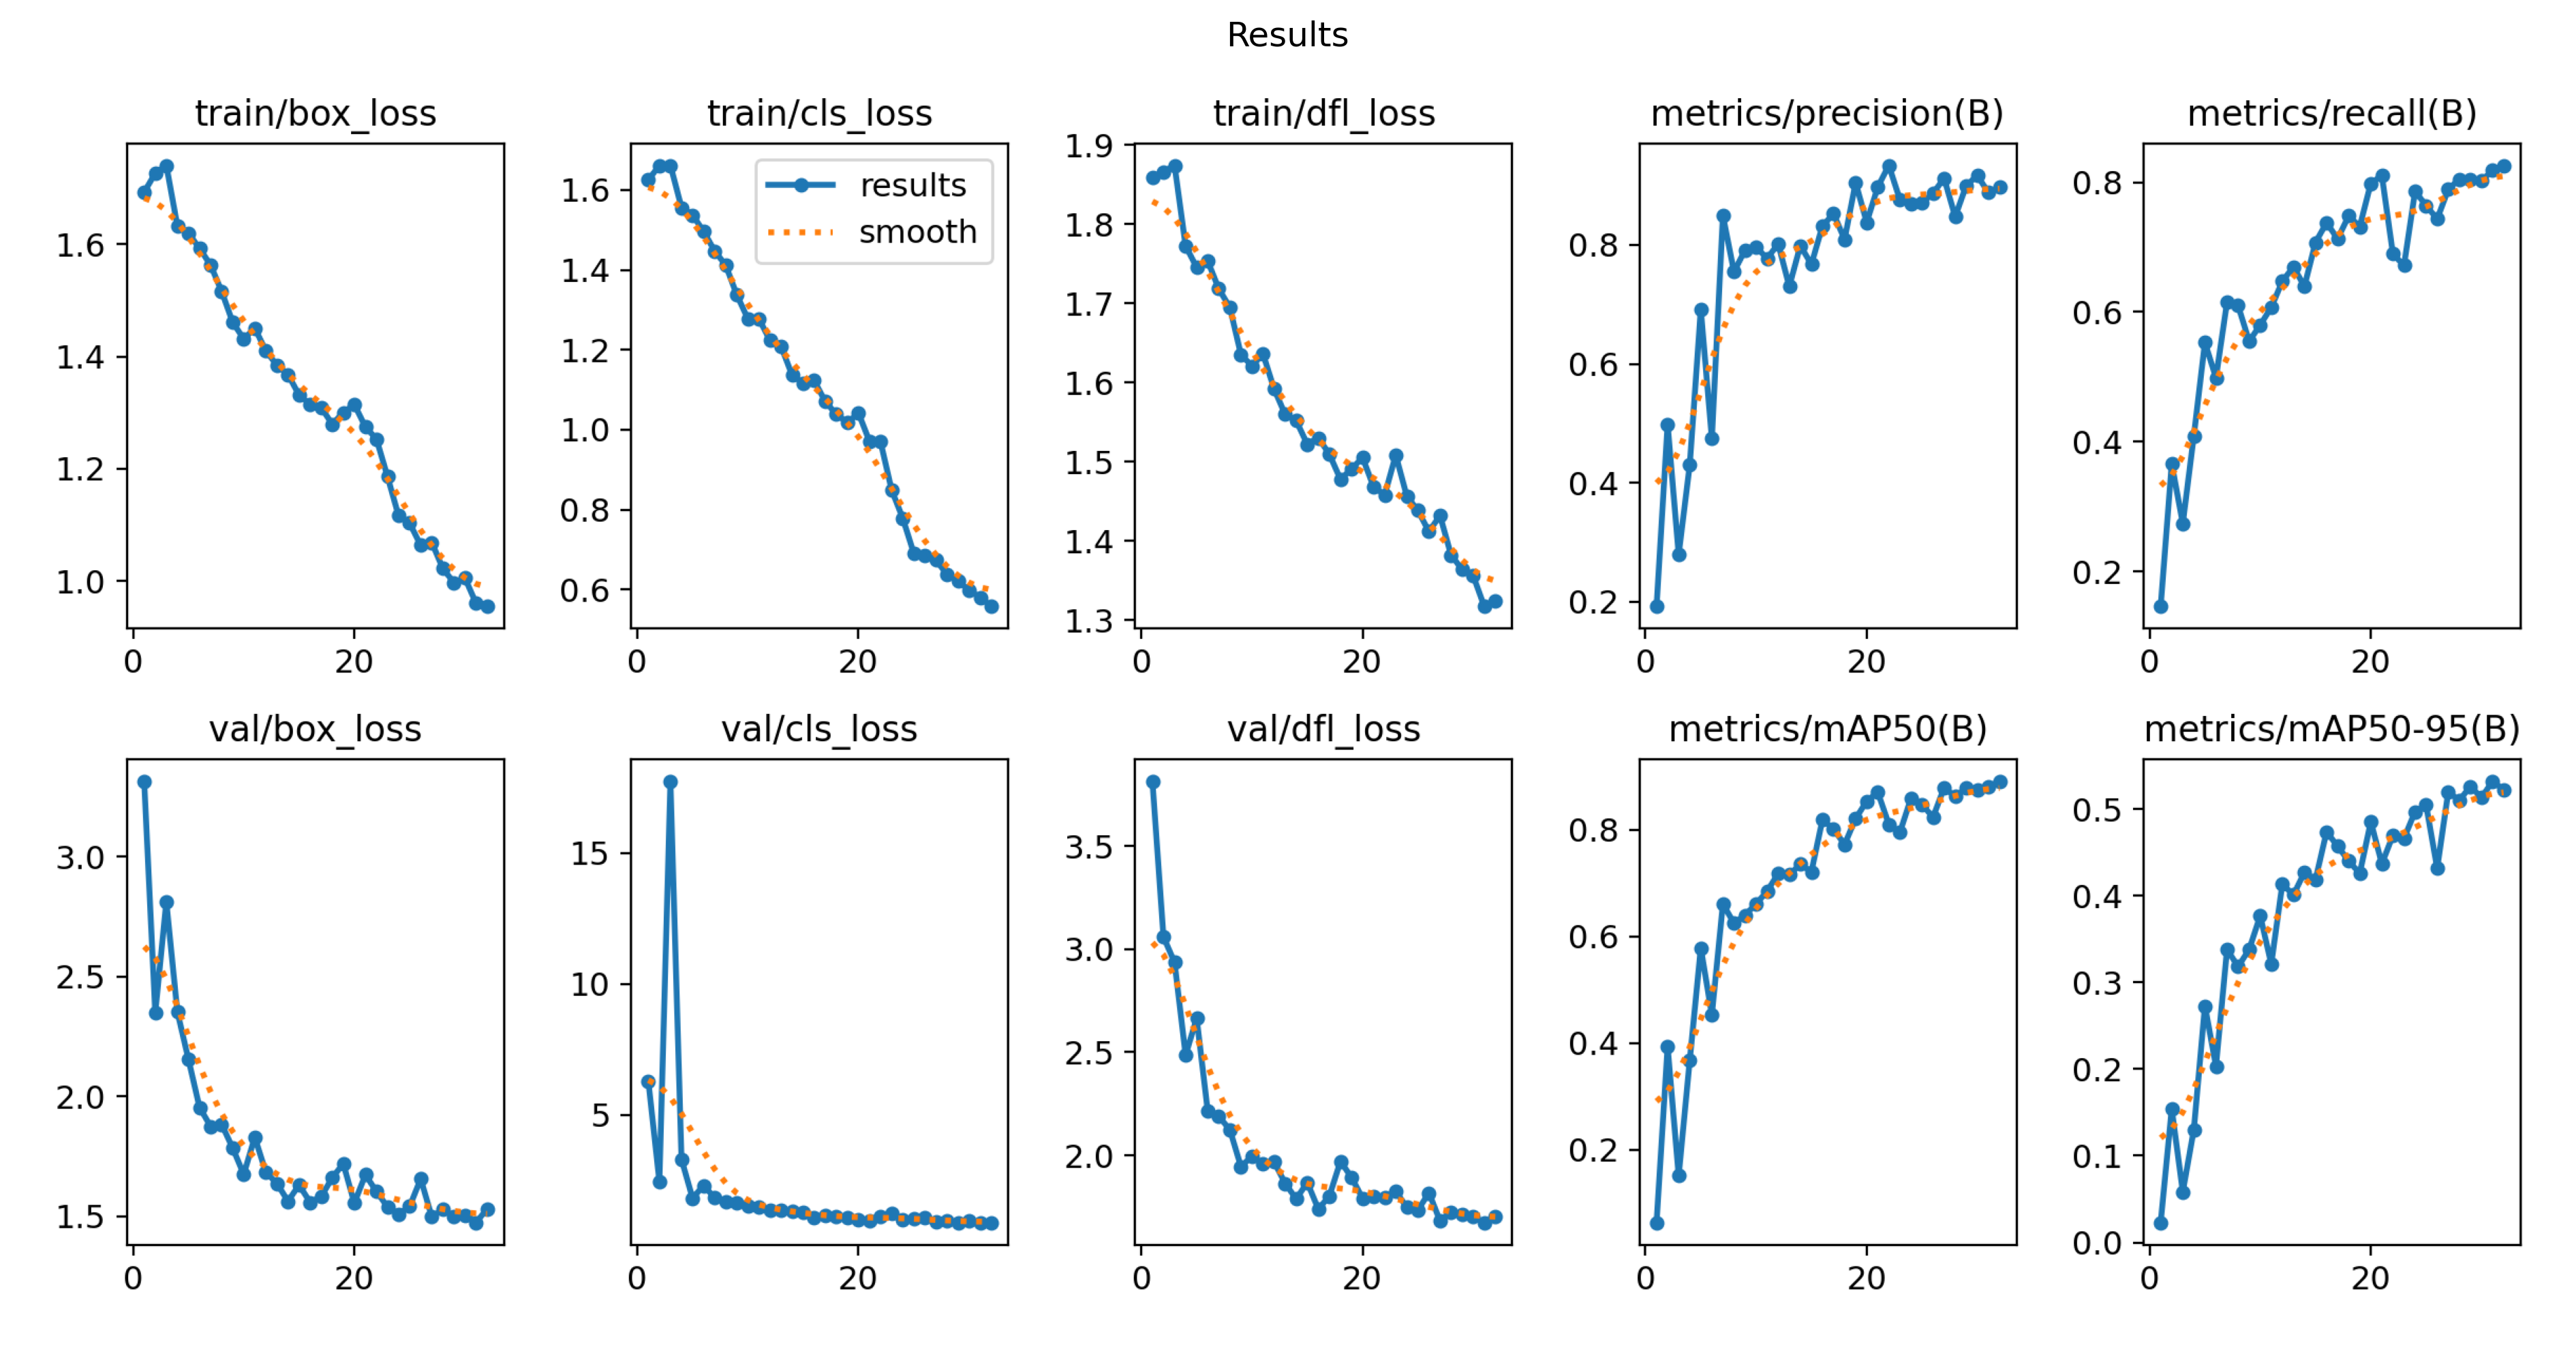

In [28]:
image = mpimg.imread('/content/runs/detect/train3/results.png')
plt.figure(figsize=(16, 9), dpi=300)
plt.title('Results')
plt.imshow(image)
plt.axis('off')
plt.show()

To calculate *mAP @ 0.5*, the model's predicted bounding boxes are compared to the ground truth bounding boxes for various objects in the dataset. The average precision (AP) is computed for each class at an IoU threshold of 0.5, and then the mean of these average precision scores is calculated across all classes. *mAP @ 0.5* provides an overall measure of the model's detection performance, indicating how well it can identify objects with a reasonable overlap threshold.

## **4. Inference and Visualization**

After training, the optimal model weights located at `/content/runs/detect/train/weights/best.pt` were used for real-time inference and drone tracking. This phase validated the YOLOv11x model’s ability to detect and track drones within video streams.

The model was loaded and applied to a test video using:

**Explanation:**

* **`model.track`**: Runs the detection and tracking pipeline.
* **`conf=0.3`**: Filters detections below 30% confidence.
* **`iou=0.5`**: Sets the IoU threshold for Non-Maximum Suppression.
* **`show=True`**: Displays the video feed with tracking annotations.





In [32]:
model = YOLO("/content/runs/detect/train3/weights/best.pt")
result = model.track(
    source="/content/tt.mp4",
    conf=0.3,
    iou=0.5,
    show=False,
    imgsz=640,
    save=True,
    project="my_outputs",
    name="tracking_output",
    exist_ok=True  # overwrite if folder exists
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/552) /content/tt.mp4: 384x640 1 drone, 62.3ms
video 1/1 (frame 2/552) /content/tt.mp4: 384x640 1 drone, 40.2ms
video 1/1 (frame 3/552) /content/tt.mp4: 384x640 1 drone, 40.2ms
video 1/1 (frame 4/552) /content/tt.mp4: 384x640 1 drone, 40.4ms
video 1/1 (frame 5/552) /content/tt.mp4: 384x640 1 drone, 39.2ms
video 1/1 (frame 6/552) /content/tt.mp4: 384x640 1 drone, 35.1ms
video 1/1 (frame 7/552) /content/tt.mp4: 384x640 1 drone, 34.1ms
vid

In [42]:
from google.colab import files
files.download('/content/my_outputs/tracking_output/heatmap_output.mp4')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In addition to tracking, a heatmap visualization was implemented to identify regions with higher drone activity. This was done using OpenCV and a YOLO-based heatmap solution:

In [38]:
import numpy as np
import os
os.makedirs("/content/my_outputs/tracking_output", exist_ok=True)

In [39]:
cap = cv2.VideoCapture("/content/tt.mp4")

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter("/content/my_outputs/tracking_output/heatmap_output.mp4", fourcc, fps, (width, height))

heatmap = solutions.Heatmap(
    colormap=cv2.COLORMAP_JET,
    show=False,
    model="/content/runs/detect/train3/weights/best.pt"
)

while cap.isOpened():
    success, im0 = cap.read()
    if not success:
        break

    results = heatmap(im0)
    processed_img = results.plot_im

    processed_img_bgr = cv2.cvtColor(processed_img, cv2.COLOR_RGB2BGR)

    out.write(processed_img_bgr)

cap.release()
out.release()
cv2.destroyAllWindows()

print("Video processing complete. Saved to /content/my_outputs/tracking_output/heatmap_output.mp4")

Ultralytics Solutions: ✅ {'source': None, 'model': '/content/runs/detect/train3/weights/best.pt', 'classes': None, 'show_conf': True, 'show_labels': True, 'region': None, 'colormap': 2, 'show_in': True, 'show_out': True, 'up_angle': 145.0, 'down_angle': 90, 'kpts': [6, 8, 10], 'analytics_type': 'line', 'figsize': (12.8, 7.2), 'blur_ratio': 0.5, 'vision_point': (20, 20), 'crop_dir': 'cropped-detections', 'json_file': None, 'line_width': 2, 'records': 5, 'fps': 30.0, 'max_hist': 5, 'meter_per_pixel': 0.05, 'max_speed': 120, 'show': False, 'iou': 0.7, 'conf': 0.25, 'device': None, 'max_det': 300, 'half': False, 'tracker': 'botsort.yaml', 'verbose': True, 'data': 'images'}
0: 720x1280 21.8ms, 1 drone
Speed: 801.7ms track, 21.8ms solution per image at shape (1, 3, 720, 1280)

1: 720x1280 13.3ms, 1 drone
Speed: 61.5ms track, 13.3ms solution per image at shape (1, 3, 720, 1280)

2: 720x1280 12.4ms, 1 drone
Speed: 62.4ms track, 12.4ms solution per image at shape (1, 3, 720, 1280)

3: 720x1280 

In [40]:
print(dir(results))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'available_slots', 'classwise_count', 'email_sent', 'filled_slots', 'in_count', 'out_count', 'pixels_distance', 'plot_im', 'queue_count', 'region_counts', 'speed', 'speed_dict', 'total_crop_objects', 'total_tracks', 'workout_angle', 'workout_count', 'workout_stage']


In [41]:
from IPython.display import Video
Video("/content/heatmap_output.mp4", embed=True)

**Key points:**

* **Heatmap Generation**: Aggregates detection activity to visualize drone movement density.
* **Colormap**: `cv2.COLORMAP_JET` highlights intensity variations.
* **Lightweight Model**: `/content/runs/detect/train/weights/best.pt` used for rapid heatmap generation.

This dual approach—tracking and heatmap visualization—provided both temporal tracking accuracy and spatial activity insights, making it valuable for surveillance, airspace monitoring, and security analysis.


*   Video source: [@ninosouza](https://www.pexels.com/@ninosouza/)
*   Video link: [pexels](https://www.pexels.com/video/an-airborne-drone-machine-8459631/)

## **5. Save the Weights and Configuration File**

In [ ]:
# model.export(format='onnx')

In [43]:
!mv /content/my_outputs /content/runs/detect/

mv: cannot move '/content/my_outputs' to '/content/runs/detect/my_outputs': Directory not empty


In [44]:
!zip -r '/content/results.zip' '/content/runs/detect/'

  adding: content/runs/detect/ (stored 0%)
  adding: content/runs/detect/train3/ (stored 0%)
  adding: content/runs/detect/train3/val_batch2_labels.jpg (deflated 15%)
  adding: content/runs/detect/train3/confusion_matrix.png (deflated 36%)
  adding: content/runs/detect/train3/train_batch2.jpg (deflated 14%)
  adding: content/runs/detect/train3/confusion_matrix_normalized.png (deflated 36%)
  adding: content/runs/detect/train3/args.yaml (deflated 52%)
  adding: content/runs/detect/train3/val_batch2_pred.jpg (deflated 14%)
  adding: content/runs/detect/train3/train_batch2796.jpg (deflated 25%)
  adding: content/runs/detect/train3/train_batch1.jpg (deflated 13%)
  adding: content/runs/detect/train3/BoxPR_curve.png (deflated 21%)
  adding: content/runs/detect/train3/results.csv (deflated 59%)
  adding: content/runs/detect/train3/weights/ (stored 0%)
  adding: content/runs/detect/train3/weights/last.pt (deflated 8%)
  adding: content/runs/detect/train3/weights/best.pt (deflated 8%)
  adding

In [45]:
files.download('/content/data.yaml')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [46]:
files.download('/content/results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!mv /content/results.zip /content/gdrive/MyDrive/

## **Results and Discussion**

We present comprehensive results of our drone detection model's performance on both the training and testing datasets. The evaluation metrics include precision, recall, and F1-score, which are standard measures to assess the model's detection accuracy.

## **Conclusion**

Our research addresses the critical need for reliable drone detection systems by proposing a comprehensive dataset and a state-of-the-art detection model using the YOLOv11x architecture. The availability of our curated dataset and the promising performance of our model offer valuable contributions to the field of drone detection. The outcomes of this study can pave the way for enhanced security measures and privacy protection in areas where drones pose potential risks.

## **Contact Me**
<p>If you have something to say to me please contact me:</p>

<ul>
  <li>Mail address: doguilmak@gmail.com</li>
</ul>

In [ ]:
from datetime import datetime
print(f"Changes have been made to the project on {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Changes have been made to the project on 2025-08-09 13:11:09
